# `trainer.ipynb` — How BiRefNet was fine-tuned on the Hypersim room dataset

This notebook is a **guided, runnable walkthrough** of the whole fine-tune, from raw data to trained
checkpoint. It explains the *why* behind each choice for our hardware (RTX 5070, 12 GB).

**Goal of the training:** teach the pretrained BiRefNet matting model to segment **everything that is
NOT room structure** (all furniture / movable objects) so the pipeline can remove them and inpaint an empty room.

**Data:** [Hypersim](https://github.com/apple/ml-hypersim) (Apple) — photorealistic *synthetic* indoor scenes,
**CC BY-SA 3.0 (commercial OK)**, with pixel-perfect rendered semantic labels.

Heavy steps (download, full training) are **guarded by flags** and OFF by default, so *Run All* stays fast.
Reference docs (don't duplicate here): `hq-mat/BiRefNet/hypersim_prep/README.md`.

Pipeline:
`download (tonemap+semantic) → NYU40→binary mask → resize 640 + scene-split → fine-tune BiRefNet → validate`


## 0. Setup & paths

In [1]:
import os, sys, glob, json
from pathlib import Path
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

ROOT   = Path("/home/krist/works/refine-mask")
REPO   = ROOT / "hq-mat" / "BiRefNet"          # BiRefNet code + config + checkpoints
PREP   = REPO / "hypersim_prep"                # our data-prep scripts
DATASET = Path.home() / "datasets/dis/General/HypersimRooms"   # train set (BiRefNet layout)
VALSET  = Path.home() / "datasets/dis/hypersim_val"            # held-out val (by scene)
sys.path.insert(0, str(REPO))                  # so `from models.birefnet import BiRefNet` works
os.chdir(REPO)                                 # config.py resolves its paths relative to here

# --- heavy-step guards (leave False for a quick Run-All) ---
RUN_DOWNLOAD   = False   # re-download Hypersim (slow, network)
RUN_TRAIN_DEMO = False   # run a couple of real training iterations (needs GPU)

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
print("dataset train imgs:", len(list((DATASET/'im').glob('*.jpg'))) if (DATASET/'im').exists() else 0)
print("val imgs:", len(list((VALSET/'im').glob('*.jpg'))) if (VALSET/'im').exists() else 0)


torch 2.12.0+cu130 | cuda True | NVIDIA GeForce RTX 5070
dataset train imgs: 1216
val imgs: 208


## 1. The label definition — the single most important design choice

BiRefNet outputs one foreground mask. We **redefine** foreground as *everything non-structure*:

| | NYU40 class ids | in mask |
|---|---|---|
| **Background (0)** = room shell | 1 wall, 2 floor, 8 door, 9 window, 22 ceiling, 38 otherstructure (+ void −1/0) | black |
| **Foreground (255)** = removable | *every other id* (furniture, appliances, curtains, mirror, lamp, plant, clutter, person…) | white |

Change `BG_IDS` below to change what counts as "structure".

In [2]:
# NYU40 background = architectural shell; everything else -> foreground (removable)
BG_IDS = {1, 2, 8, 9, 22, 38}   # wall, floor, door, window, ceiling, otherstructure

def sem_to_mask(sem):
    """NYU40 semantic (int16, -1..40) -> boolean foreground (non-structure)."""
    return (~np.isin(sem, list(BG_IDS))) & (sem >= 1)   # labeled AND not shell


## 2. Download — only what we need (keeps it tiny)

Full Hypersim is ~1.9 TB. We use the per-file downloader (`hypersim_prep/download.py`, by 99991) to pull
**only** `*.tonemap.jpg` (input) + `*.semantic.hdf5` (labels), cam_00, 10 frames/scene. That is ~**165 MB** for 180 scenes.

`hypersim_prep/fetch.sh` loops `scenes.txt` and does two filtered passes per scene:
```bash
python download.py -d raw --scene <id> -c scene_cam_00_final_preview -c frame.000 -c tonemap.jpg -s
python download.py -d raw --scene <id> -c scene_cam_00_geometry_hdf5 -c frame.000 -c semantic.hdf5 -s
```
A tiny 3-frame sample lives in `hypersim_prep/sample_raw/` so this notebook runs without downloading.

In [3]:
SAMPLE_RAW = PREP / "sample_raw"
sample_sems = sorted(SAMPLE_RAW.glob("**/*.semantic.hdf5"))
print("sample frames:", [p.name for p in sample_sems])

if RUN_DOWNLOAD:
    # re-download the full set (writes hypersim_prep/raw). Slow.
    import subprocess
    subprocess.run(["bash", str(PREP/"fetch.sh")], cwd=PREP, check=True)


sample frames: ['frame.0000.semantic.hdf5', 'frame.0003.semantic.hdf5', 'frame.0006.semantic.hdf5']


## 3. See the label mapping on a real frame

Load one Hypersim semantic map, look at which NYU40 ids are present, then apply `sem_to_mask`
and overlay the result. This is exactly the ground truth the model learns from.

NYU40 ids present (id:pixels): {1: 435617, 9: 78107, 2: 71738, 13: 57575, 36: 35663, 19: 34434, 3: 31666, 34: 16219, 27: 9326, 40: 7483}
foreground = 25.1% of pixels


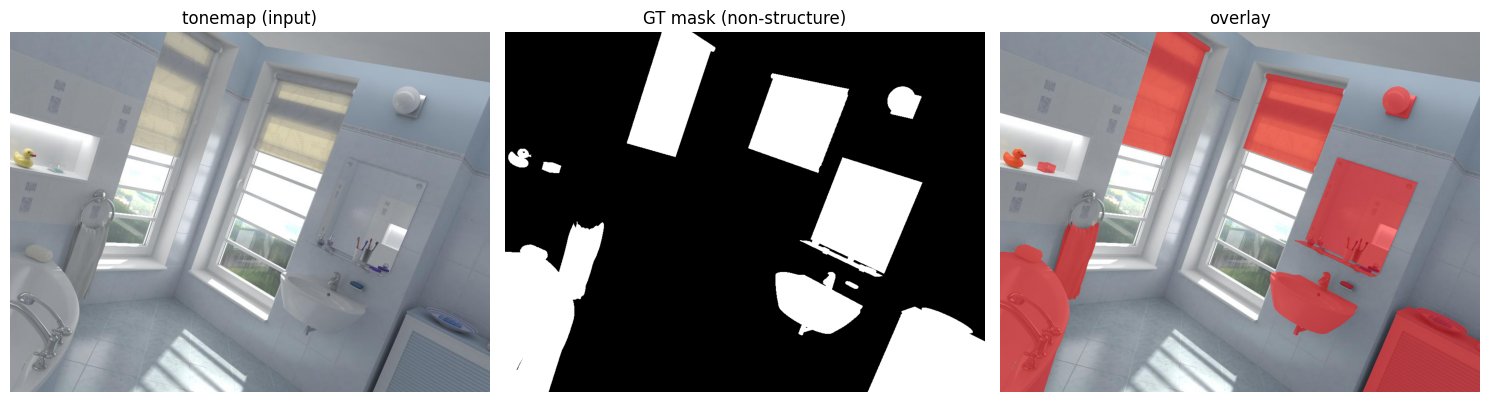

In [4]:
sp = sample_sems[0]
frame = sp.name.split('.semantic')[0]
jp = sp.parent.parent / "scene_cam_00_final_preview" / f"{frame}.tonemap.jpg"

sem = h5py.File(sp, 'r')['dataset'][:].astype(np.int16)   # (768,1024) NYU40 ids
img = np.array(Image.open(jp).convert('RGB'))
fg  = sem_to_mask(sem)

ids, cnts = np.unique(sem, return_counts=True)
print("NYU40 ids present (id:pixels):",
      {int(i): int(c) for i, c in sorted(zip(ids, cnts), key=lambda x:-x[1])[:10]})
print(f"foreground = {fg.mean()*100:.1f}% of pixels")

ov = img.copy(); ov[fg] = (0.5*ov[fg] + 0.5*np.array([255,0,0])).astype(np.uint8)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, im, t in zip(ax, [img, fg.astype(float), ov],
                    ["tonemap (input)", "GT mask (non-structure)", "overlay"]):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 4. Build the BiRefNet training set

`hypersim_prep/extract.py` turns raw frames into BiRefNet's expected layout:

```
~/datasets/dis/General/HypersimRooms/im/*.jpg   +   gt/*.png     (train)
~/datasets/dis/hypersim_val/{im,gt}                              (val)
```

Key steps: **resize to 640×640** (our GPU limit, see §5), filter degenerate frames
(<50% labeled, or FG outside 2–98%), and **split by SCENE (85/15)** — not by frame — so near-duplicate
frames of the same room can't leak between train and val. Result: **1216 train / 208 val**.

SIZE = (640, 640)            # (W,H) — RTX 5070 12GB training resolution
VAL_FRAC = 0.15
BG_IDS = {1, 2, 8, 9, 22, 38}   # wall, floor, door, window, ceiling, otherstructure
MIN_VALID = 0.50   # >=50% pixels labeled (id>=1)
MIN_FG    = 0.02   # foreground between 2%..98%
MAX_FG    = 0.98
n_val = max(1, int(len(scenes) * VAL_FRAC))
if valid < MIN_VALID:
if fgfrac < MIN_FG or fgfrac > MAX_FG:


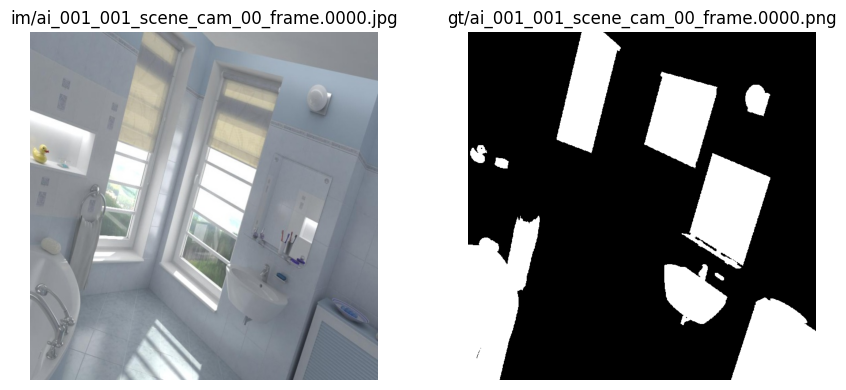

In [5]:
# show the extraction thresholds straight from the script
src = (PREP/"extract.py").read_text()
for line in src.splitlines():
    if any(k in line for k in ["SIZE =", "VAL_FRAC", "MIN_VALID", "MIN_FG", "MAX_FG", "BG_IDS ="]):
        print(line.strip())

# peek at one produced train pair
im0 = sorted((DATASET/'im').glob('*.jpg'))[0]
gt0 = DATASET/'gt'/(im0.stem + '.png')
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(Image.open(im0)); ax[0].set_title('im/'+im0.name); ax[0].axis('off')
ax[1].imshow(Image.open(gt0), cmap='gray'); ax[1].set_title('gt/'+gt0.name); ax[1].axis('off')
plt.tight_layout(); plt.show()


## 5. Config for RTX 5070 (12 GB) — why these numbers

BiRefNet's defaults target an A100 (76 GB). Measured fwd+bwd peak on our card:
**1024² = 12.8 GB (OOM)**, 768² = 9.1 GB (too tight), **640² = 7.8 GB ✓**.

Edits made in `hq-mat/BiRefNet/config.py`:

| setting | default | ours | why |
|---|---|---|---|
| `size` | (1024,1024) | **(640,640)** | fit 12 GB |
| `batch_size` | 8 | **1** | fit 12 GB |
| `compile` | True | **False** | Blackwell + torch 2.12 inductor flaky |
| `task` | DIS5K | **General** | hard masks (Hypersim has no alpha), not Matting |
| `finetune_last_epochs['General']` | −20 | **−8** | fewer boundary-reweighted epochs on a short run |

`lr` auto-derives to **5e-6** (low = safe fine-tune). Note: with `batch_size=1`, BiRefNet swaps every
BatchNorm → `nn.Identity` (memorize this — it drives §6 and the notebook-load fix).

In [6]:
from config import Config
c = Config()
for k in ["task", "size", "batch_size", "compile", "lr", "finetune_last_epochs"]:
    print(f"{k:22s}= {getattr(c, k)}")
print("training_set          =", c.training_set)


task                  = General
size                  = (640, 640)
batch_size            = 1
compile               = False
lr                    = 5e-06
finetune_last_epochs  = -8
training_set          = HypersimRooms


## 6. Pretrained init — and the BatchNorm gotcha

We fine-tune *from* the public `zhengpeng7/birefnet` weights, not from scratch. Two wrinkles:

1. `train.py` loads a `.pth` via `--resume` with a **strict** `load_state_dict`, but the HF weights are
   `.safetensors` and carry **215 surplus BatchNorm keys**. So we load `strict=False` then re-save the
   model's *own* `state_dict` → `pretrained_init/epoch_0.pth` (named so train.py's epoch parser yields epoch 1).
2. Because we build at `batch_size=1`, the model has **no BN layers** (they're `Identity`). Any code that
   later loads our checkpoints must also build at bs=1, or `load_state_dict` fails with *"Missing key(s) …bn…"*.
   (That's exactly the fix applied in `main_gd.ipynb`'s load cell.)

The conversion (already done — file exists):

In [7]:
# This is how pretrained_init/epoch_0.pth was made (guarded; file already exists).
init_pth = REPO / "pretrained_init/epoch_0.pth"
print("pretrained_init exists:", init_pth.exists())

if not init_pth.exists():
    from safetensors.torch import load_file
    from utils import check_state_dict
    from models.birefnet import BiRefNet
    sf = glob.glob(os.path.expanduser(
        '~/.cache/huggingface/hub/models--zhengpeng7--birefnet/snapshots/*/model.safetensors'))[0]
    m = BiRefNet(bb_pretrained=False)
    miss, unexp = m.load_state_dict(check_state_dict(load_file(sf)), strict=False)
    print("missing", len(miss), "unexpected(BN surplus)", len(unexp))
    init_pth.parent.mkdir(exist_ok=True)
    torch.save(m.state_dict(), init_pth)   # exact-key -> strict-loadable


pretrained_init exists: True


## 7. Train

Run from `hq-mat/BiRefNet/` (single-GPU, mixed bf16 via accelerate):

```bash
python train.py --ckpt_dir ckpts/hypersim --epochs 30 --dist False \
    --resume pretrained_init/epoch_0.pth --use_accelerate
```

- Loss (`task=General`): weighted **BCE + IoU + SSIM + MAE** (multi-scale deep supervision).
- ~0.25 s/iter on the 5070 → ~6.5 min/epoch → **~3.2 h for 30 epochs**.
- Checkpoints saved every 5 epochs → `ckpts/hypersim/epoch_{5,10,…,30}.pth`.
- The last 8 epochs drop BCE and lean on IoU/SSIM to sharpen boundaries.

The cell below runs a **tiny 2-iteration demo** (only if `RUN_TRAIN_DEMO=True`) so you can see one
forward/backward without the full run.

In [8]:
if RUN_TRAIN_DEMO:
    import torch.nn as nn
    from models.birefnet import BiRefNet
    from torchvision import transforms
    tf = transforms.Compose([transforms.Resize((640,640)), transforms.ToTensor(),
                             transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    tfl = transforms.Compose([transforms.Resize((640,640)), transforms.ToTensor()])
    m = BiRefNet(bb_pretrained=False).cuda().train()
    m.load_state_dict(torch.load(REPO/'pretrained_init/epoch_0.pth', weights_only=True))
    opt = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad], lr=5e-6)
    ims = sorted((DATASET/'im').glob('*.jpg'))[:2]
    for i, ip in enumerate(ims):
        x = tf(Image.open(ip).convert('RGB')).unsqueeze(0).cuda()
        y = tfl(Image.open(DATASET/'gt'/(ip.stem+'.png')).convert('L')).unsqueeze(0).cuda()
        with torch.autocast('cuda', dtype=torch.bfloat16):
            preds = m(x)
            p = preds[-1] if not isinstance(preds[0], (list,tuple)) else preds[-1]
            while isinstance(p, (list,tuple)): p = p[-1]
            loss = nn.functional.binary_cross_entropy_with_logits(
                nn.functional.interpolate(p.float(), size=(640,640)), y)
        opt.zero_grad(); loss.backward(); opt.step()
        print(f"iter {i}: loss={loss.item():.4f}")
    del m, opt; torch.cuda.empty_cache()
else:
    print("RUN_TRAIN_DEMO=False — skipping. Set True to run 2 real iterations.")


RUN_TRAIN_DEMO=False — skipping. Set True to run 2 real iterations.


## 8. Validate — in-domain metrics + the real-domain test

The honest test is the **synthetic→real gap**. `hypersim_prep/validate.py` reports metrics on the held-out
Hypersim val set AND writes overlays on real rooms (`users_yolo/*/original.jpg`).

epoch_30 on hypersim_val: **IoU 0.683 · Fβ 0.783 · MAE 0.083 · boundaryIoU 0.210**.

Below: load a checkpoint (with the **bs=1 build**, per §6) and run it on one validation image.

/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


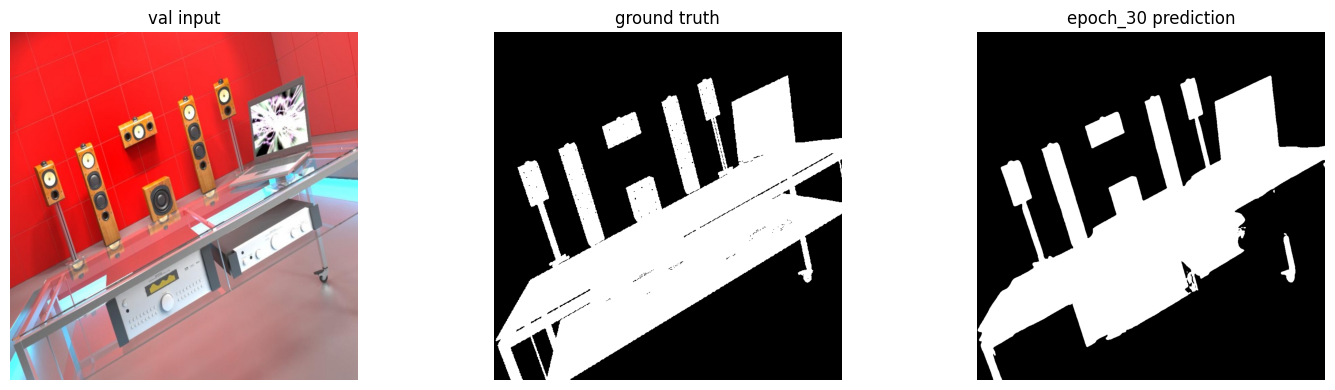

run `python hypersim_prep/validate.py` for full metrics + real-room overlays


In [9]:
EPOCH = 30   # try 15 / 20 / 30 to compare
ckpt = REPO / f"ckpts/hypersim/epoch_{EPOCH}.pth"

# build at batch_size=1 so architecture (BN=Identity) matches the checkpoint
import models.birefnet as _bn
from models.modules import aspp as _aspp, decoder_blocks as _dec
_aspp.config.batch_size = 1; _dec.config.batch_size = 1
class _BS1(_bn.Config):
    def __init__(self, *a, **k): super().__init__(*a, **k); self.batch_size = 1
_bn.Config = _BS1

from torchvision import transforms
model = _bn.BiRefNet(bb_pretrained=False)
model.load_state_dict(torch.load(ckpt, weights_only=True))   # strict OK at bs=1
model = model.cuda().eval()
tf = transforms.Compose([transforms.Resize((1024,1024)), transforms.ToTensor(),
                         transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

vp = sorted((VALSET/'im').glob('*.jpg'))[0]
vg = VALSET/'gt'/(vp.stem+'.png')
im = Image.open(vp).convert('RGB')
with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
    pred = model(tf(im).unsqueeze(0).cuda().half())[-1].sigmoid().float().cpu()[0,0].numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(im); ax[0].set_title('val input'); ax[0].axis('off')
ax[1].imshow(Image.open(vg), cmap='gray'); ax[1].set_title('ground truth'); ax[1].axis('off')
ax[2].imshow(pred > 0.5, cmap='gray'); ax[2].set_title(f'epoch_{EPOCH} prediction'); ax[2].axis('off')
plt.tight_layout(); plt.show()
print("run `python hypersim_prep/validate.py` for full metrics + real-room overlays")


## 9. Training curve & validation confusion matrix

The per-epoch training loss is logged to `ckpts/hypersim/log.txt`. The **confusion matrix** is pixel-level,
binary (FG = non-structure vs BG = structure), computed on the 208 held-out val images at threshold 0.5,
using the `model` loaded in §8.

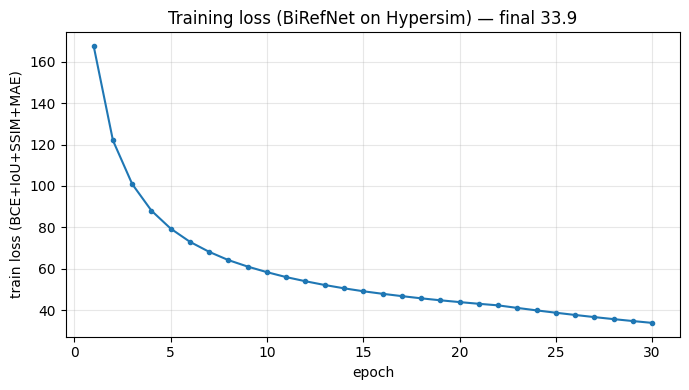

In [10]:
import re
log = (REPO/"ckpts/hypersim/log.txt").read_text()
ep = sorted(set((int(a), float(b)) for a, b in
                re.findall(r"Epoch\[(\d+)/30\]\s+Training Loss:\s+([\d.]+)", log)))
xs = [e for e, _ in ep]; ys = [l for _, l in ep]
plt.figure(figsize=(7, 4))
plt.plot(xs, ys, marker="o", ms=3)
plt.title(f"Training loss (BiRefNet on Hypersim) — final {ys[-1]:.1f}")
plt.xlabel("epoch"); plt.ylabel("train loss (BCE+IoU+SSIM+MAE)"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

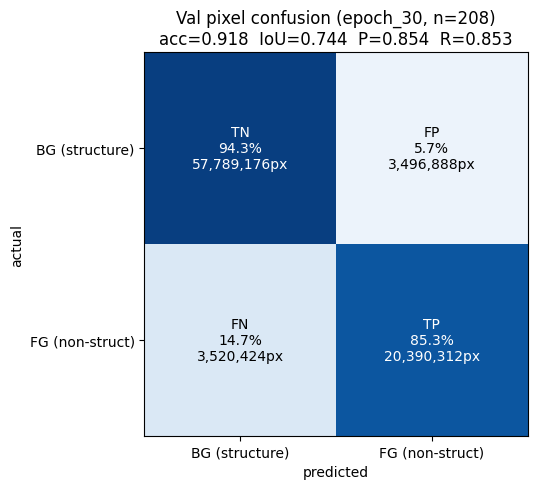

accuracy=0.9176 precision=0.8536 recall=0.8528 IoU=0.7440


In [11]:
from torchvision import transforms
tf640 = transforms.Compose([transforms.Resize((640,640)), transforms.ToTensor(),
                            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
TP=FP=FN=TN=0
val_imgs = sorted((VALSET/'im').glob('*.jpg'))
for ip in val_imgs:
    g = np.array(Image.open(VALSET/'gt'/(ip.stem+'.png')).convert('L').resize((640,640), Image.NEAREST)) > 127
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        pr = model(tf640(Image.open(ip).convert('RGB')).unsqueeze(0).cuda().half())[-1].sigmoid().float().cpu()[0,0].numpy()
    pb = pr > 0.5
    TP += int((pb & g).sum()); FP += int((pb & ~g).sum()); FN += int((~pb & g).sum()); TN += int((~pb & ~g).sum())

cm = np.array([[TN, FP], [FN, TP]], float); tot = cm.sum()
acc=(TP+TN)/tot; prec=TP/(TP+FP); rec=TP/(TP+FN); iou=TP/(TP+FP+FN)
cmn = cm / cm.sum(1, keepdims=True); names=[['TN','FP'],['FN','TP']]; labs=['BG (structure)','FG (non-struct)']
plt.figure(figsize=(5.5,5))
plt.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
plt.xticks([0,1], labs); plt.yticks([0,1], labs); plt.xlabel('predicted'); plt.ylabel('actual')
plt.title(f'Val pixel confusion (epoch_{EPOCH}, n={len(val_imgs)})\nacc={acc:.3f}  IoU={iou:.3f}  P={prec:.3f}  R={rec:.3f}')
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{names[i][j]}\n{cmn[i,j]*100:.1f}%\n{int(cm[i,j]):,}px",
                 ha='center', va='center', color='black' if cmn[i,j]<0.6 else 'white')
plt.tight_layout(); plt.show()
print(f"accuracy={acc:.4f} precision={prec:.4f} recall={rec:.4f} IoU={iou:.4f}")

## Recap — reproduce end to end

```bash
conda activate birefnet
cd hq-mat/BiRefNet
bash hypersim_prep/fetch.sh                 # 1. download (~165 MB)
python hypersim_prep/extract.py             # 2. NYU40->binary, 640, scene-split  -> ~/datasets/dis/...
# 3. config.py already set for 5070 (640 / bs1 / compile off / General)
# 4. pretrained_init/epoch_0.pth already made from zhengpeng7/birefnet (safetensors->pth)
python train.py --ckpt_dir ckpts/hypersim --epochs 30 --dist False \
    --resume pretrained_init/epoch_0.pth --use_accelerate     # 5. train ~3.2 h
python hypersim_prep/validate.py            # 6. metrics + real overlays
```

**Remember the two gotchas:** foreground = *everything non-structure* (edit `BG_IDS`), and checkpoints
are bs=1 so any loader must build at bs=1 (BN → Identity). See `hypersim_prep/README.md`.